# Import Labraries

In [1]:
import torch
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sbn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# Load Files

In [2]:
train_data = pd.read_csv("../input/digit-recognizer/train.csv")
test_data = pd.read_csv("../input/digit-recognizer/test.csv")
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#shape
print(f'training data shape: {train_data.shape}\ntesting data shape: {test_data.shape}')

training data shape: (42000, 785)
testing data shape: (28000, 784)


In [4]:
#Train Test Split
train_set, val_set = train_test_split(train_data, test_size=0.01, random_state=10)
train_set.shape, val_set.shape

((41580, 785), (420, 785))

# Visualize a sample

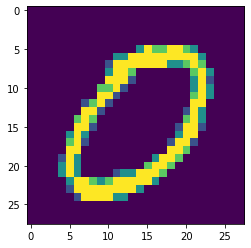

In [5]:
plt.imshow(train_set.iloc[0, 1:].to_numpy().reshape(28, 28))
plt.show()

# Create the DataLoader

In [6]:
class mnistDataset(Dataset):
    def __init__(self, df):
        self.df = df
        x = self.df.iloc[:,1:]
        y = self.df.label
        self.x = torch.tensor(np.array(x).reshape(-1, 1, 28, 28), dtype=torch.float)/255
        self.y = torch.tensor(np.array(y), dtype=torch.float)
        
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    
    def __len__(self):
        return self.df.shape[0]

In [7]:
train_mnistDataset = mnistDataset(train_set)
val_mnistDataset = mnistDataset(val_set)

In [8]:
BATCH_SIZE = 64
train_data_loader = DataLoader(dataset=train_mnistDataset, batch_size=BATCH_SIZE, shuffle=True)
val_data_loader = DataLoader(dataset=val_mnistDataset, batch_size=BATCH_SIZE, shuffle=True)

In [9]:
#shape of the data in train_data_loader
for data, label in train_data_loader:
    print(data.shape)
    print(label.shape)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64])


#  Download and use pre-trained model for transfer learning

In [10]:
model = models.resnet50(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

In [11]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Count No. of Trainable Parameters

In [12]:
def count_params(model):
    model_params = {'Modules': list(), 'Parameters':list()}
    Total = {'trainable_parameters' : 0, 'non-trainable_parameters' : 0}
    for name, parameters in model.named_parameters():
        param = parameters.numel()
        if not parameters.requires_grad:
            Total['non-trainable_parameters'] += param
            continue
        model_params['Modules'].append(name)
        model_params['Parameters'].append(param)
        Total['trainable_parameters'] += param
    df = pd.DataFrame(model_params)
    return df, Total

df, Total = count_params(model)
print(f"trainable parameters: {Total['trainable_parameters']}, non-trainable parameters: {Total['non-trainable_parameters']}")
df

trainable parameters: 25557032, non-trainable parameters: 0


,Modules,Parameters
0,conv1.weight,9408
1,bn1.weight,64
2,bn1.bias,64
3,layer1.0.conv1.weight,4096
4,layer1.0.bn1.weight,64
...,...,...
156,layer4.2.conv3.weight,1048576
157,layer4.2.bn3.weight,2048
158,layer4.2.bn3.bias,2048
159,fc.weight,2048000


In [13]:
# Freezing all the model layers
for parameters in model.parameters():
    parameters.requires_grad = False

In [14]:
count_params(model)

(Empty DataFrame
 Columns: [Modules, Parameters]
 Index: [],
 {'trainable_parameters': 0, 'non-trainable_parameters': 25557032})

In [15]:
#Lets' Tweek the Resnet Model
model.conv1 = nn.Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(3, 3), bias=False)
model.maxpool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
model.fc = nn.Linear(in_features=2048, out_features=10, bias=True)

In [16]:
#New Resnet Model
print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Train the Model

In [17]:
EPOCHS= 10
#Loss and Optimizer
Criterion_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [19]:
for epoch in range(EPOCHS):
    with tqdm(train_data_loader) as tqdm_epoch:
        for images, labels in tqdm_epoch:
            tqdm_epoch.set_description(f"Epoch {epoch + 1} / {EPOCHS}")
            images = images.to(device)
            labels = labels.type(torch.LongTensor).to(device)
        
            #Forward Propagation
            pred = model(images)
            loss = Criterion_loss(pred, labels)

            #Backward Propagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            accuracy = torch.mean((torch.argmax(pred, 1)==labels).float()).item()
            tqdm_epoch.set_postfix(loss = loss.item(), accuracy = accuracy)

Epoch 10 / 10: 100%|██████████| 650/650 [1:02:57<00:00,  5.81s/it, accuracy=0.932, loss=0.204]


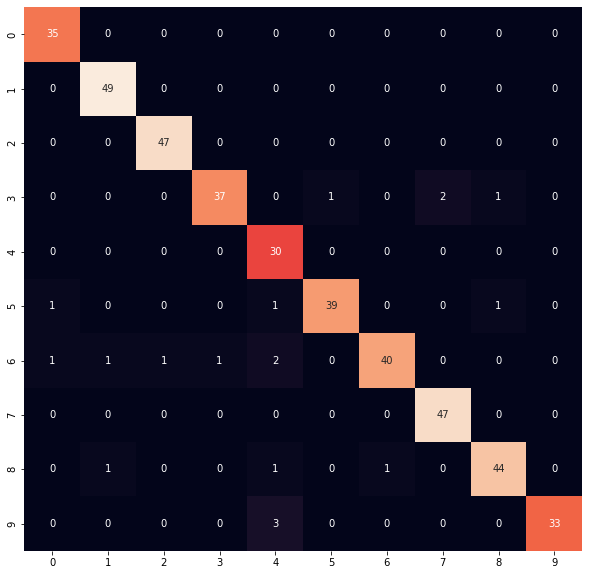

In [20]:
pred = np.array([])
target = np.array([])

with torch.no_grad():
    for batch, data in enumerate(val_data_loader):
        image, label = data[0].to(device), data[1].to(device)
        
        y_pred = model(image)
        
        pred = np.concatenate((pred, torch.argmax(y_pred, 1).cpu().numpy()))
        target = np.concatenate((target, label.cpu().numpy()))
cm = confusion_matrix(target, pred)
plt.figure(figsize=(10, 10))
sbn.heatmap(cm, annot=True, fmt = 'd', cbar=False)
plt.show()

# Submission to Kaggle

In [21]:
class testmnistDataset(Dataset):
    def __init__(self, df):
        self.df = df
        x = self.df.iloc[:,0:]
        self.x = torch.tensor(np.array(x).reshape(-1, 1, 28, 28), dtype=torch.float)/255
        
    def __getitem__(self, index):
        return self.x[index]
    
    def __len__(self):
        return self.df.shape[0]

In [22]:
test_mnistDataset = testmnistDataset(test_data)
test_data_loader = DataLoader(dataset=test_mnistDataset, batch_size=BATCH_SIZE, shuffle=False)

In [23]:
pred = np.array([])
with torch.no_grad():
    for batch, data in enumerate(test_data_loader):
        image = data.to(device)
        y_pred = model(image)
        pred = np.concatenate((pred, torch.argmax(y_pred, 1).cpu().numpy()))
ImageId = []
for i in range(len(pred)):
    ImageId.append(i+1)

In [24]:
test_data['ImageId']=ImageId
test_data['Label']=pred.astype('int')
test_data[['ImageId', 'Label']].to_csv("Submission.csv", index=False)